# AI-BASED MEDICAL WASTE SEGREGATION MONITORING SYSTEM FOR MULTI-SPECIALITY HOSPITALS

This notebook is designed to train an Ultralytics YOLOv11 Nano model for medical waste segregation, addressing the user's need to obtain a local `best.pt` model using Google Colab's Free GPU due to local hardware limitations.

## Project Context:
*   Milestone 1 and 2 are completed.
*   Roboflow Training Results:
    *   mAP@50: 95.5%
    *   Precision: 91.4%
    *   Recall: 95.4%
    *   F1 Score: 93.3%
*   The primary purpose of Colab training is to obtain a deployable local model (`best.pt`) for Milestone 3.

## System Specifications (User's Laptop):
*   Processor: 12th Gen Intel Core i7-12700H
*   RAM: 16 GB
*   Graphics: Intel Iris Xe Graphics (No NVIDIA CUDA GPU)
*   Local training crashes due to insufficient resources, hence using Google Colab Free GPU.

## Dataset Information:
*   Roboflow dataset already downloaded and extracted.
*   Dataset structure: `Biomedical_Waste/` containing `train/`, `valid/`, `test/`, `data.yaml`, etc.
*   The dataset ZIP (`Biomedical_Waste.zip`) will be uploaded manually to Google Colab.
*   `data.yaml` is pre-configured correctly.

## Final Detection Classes (8):
*   cotton
*   general_waste
*   glove
*   iv_tube
*   mask
*   medicine_bottle
*   needle
*   syringe

## Class Merging Details:
*   **needle**: needle, needle cap
*   **syringe**: used syringe
*   **cotton**: gauze, unused gauze
*   **iv_tube**: tube
*   **medicine_bottle**: fluid bottle, test tube, glass
*   **general_waste**: paper, plastic, scrub

## Waste Category Identification Rules:
*   **Sharps Waste**: needle, syringe
*   **Contaminated Recyclable Waste**: glove, mask, iv_tube
*   **Infectious Waste**: cotton
*   **Glass Waste**: medicine_bottle
*   **Non-Biomedical Waste**: general_waste

## Bin Recommendation Rules:
*   **White Bin**: Sharps Waste
*   **Red Bin**: Contaminated Recyclable Waste
*   **Yellow Bin**: Infectious Waste
*   **Blue Bin**: Glass Waste
*   **General Waste Bin**: Non-Biomedical Waste

## Part 1: Google Colab Setup - GPU Information

This section verifies the availability of a GPU and displays its specifications, which is crucial for accelerating model training.

In [19]:
import torch
import os

def check_gpu_info():
    """Checks and displays GPU availability and information."""
    print("--- GPU Availability and Information ---")
    if torch.cuda.is_available():
        print("CUDA is available. GPU is ready to use!")
        # Get GPU count
        num_gpus = torch.cuda.device_count()
        print(f"Number of GPUs available: {num_gpus}")
        for i in range(num_gpus):
            # Get GPU name
            gpu_name = torch.cuda.get_device_name(i)
            # Get GPU memory
            gpu_memory = torch.cuda.get_device_properties(i).total_memory / (1024**3) # Convert to GB
            print(f"GPU {i}:\n  Name: {gpu_name}\n  Total Memory: {gpu_memory:.2f} GB")

        # Set default device if multiple GPUs are present
        if num_gpus > 0:
            os.environ["CUDA_VISIBLE_DEVICES"] = "0" # Use the first GPU by default
            print("Using GPU 0 by default.")

    else:
        print("CUDA is NOT available. Training might be slow on CPU.")
        print("Please ensure you have selected a GPU runtime type in Colab (Runtime -> Change runtime type).")

# Execute the function to check GPU info
check_gpu_info()

--- GPU Availability and Information ---
CUDA is available. GPU is ready to use!
Number of GPUs available: 2
GPU 0:
  Name: Tesla T4
  Total Memory: 14.56 GB
GPU 1:
  Name: Tesla T4
  Total Memory: 14.56 GB
Using GPU 0 by default.


## Part 2: Install Dependencies

This section installs all necessary Python libraries, including Ultralytics for YOLO model training and inference, and other utilities like OpenCV, Matplotlib, Pandas, NumPy, and PyYAML.

In [34]:
# Install required libraries
# The --quiet flag suppresses installation output for cleaner logs.
print("Installing dependencies...")
!pip install ultralytics opencv-python matplotlib pandas numpy pyyaml --quiet
print("Dependencies installed successfully.")

Installing dependencies...
Dependencies installed successfully.


In [35]:
# Verify Ultralytics installation and display its version
try:
    import ultralytics
    print(f"Ultralytics installed. Version: {ultralytics.__version__}")
except ImportError:
    print("Ultralytics is not installed or could not be imported.")
    print("Please check the installation steps.")

Ultralytics installed. Version: 8.4.60


## Part 3: Dataset Upload

Here, you will upload your `Biomedical_Waste.zip` file to the Colab environment. This step is manual, and Colab will provide a file uploader widget.

In [36]:
DATASET_ROOT = "/kaggle/input/datasets/anush7/bio-medical-dataset/Biomedical Waste Detection dataset.v1i.yolov11"

print(os.listdir(DATASET_ROOT))

['README.dataset.txt', 'README.roboflow.txt', 'data.yaml', 'valid', 'test', 'train']


## Part 4: Dataset Extraction

This section extracts the uploaded `Biomedical_Waste.zip` into the `/content/Biomedical_Waste` directory and then displays the resulting folder structure to confirm successful extraction.

In [38]:
import os

DATASET_ROOT = "/kaggle/input/datasets/anush7/bio-medical-dataset/Biomedical Waste Detection dataset.v1i.yolov11"

print("Dataset contents:")
print(os.listdir(DATASET_ROOT))

Dataset contents:
['README.dataset.txt', 'README.roboflow.txt', 'data.yaml', 'valid', 'test', 'train']


## Part 6: Training

This section initiates the training of the YOLOv11 Nano model using transfer learning. We will use `yolo11n.pt` as a pre-trained checkpoint and configure specific training parameters suitable for the medical waste segregation task.

In [41]:
from ultralytics import YOLO

# Initialize the YOLOv11 Nano model with a pre-trained checkpoint
# This enables transfer learning, leveraging weights learned from a larger dataset.
print("Loading YOLOv11 Nano model with pre-trained weights (yolo11n.pt)...")
try:
    model = YOLO('yolo11n.pt')
    print("Model loaded successfully.")
except Exception as e:
    print(f"Error loading model: {e}")
    print("Please ensure 'yolo11n.pt' is available or check Ultralytics installation.")
    # Exit or handle the error appropriately if model loading fails
    # For this notebook, we'll proceed, but it will likely fail later if model isn't loaded.


Loading YOLOv11 Nano model with pre-trained weights (yolo11n.pt)...
Model loaded successfully.


In [44]:
import os
import yaml
from ultralytics import YOLO

# =========================
# Training Parameters
# =========================
epochs = 100
imgsz = 640
batch = -1          # Auto batch size
patience = 20       # Early stopping
project_name = "Biomedical_Waste"

# =========================
# Kaggle Dataset Path
# =========================
dataset_root_path = "/kaggle/input/datasets/anush7/bio-medical-dataset/Biomedical Waste Detection dataset.v1i.yolov11"

data_yaml_path = os.path.join(dataset_root_path, "data.yaml")

# =========================
# Load and Correct data.yaml
# =========================
print(f"Loading data.yaml from:\n{data_yaml_path}")

try:
    with open(data_yaml_path, "r") as f:
        data_yaml = yaml.safe_load(f)

    # Fix dataset paths
    data_yaml["train"] = os.path.join(dataset_root_path, "train/images")
    data_yaml["val"]   = os.path.join(dataset_root_path, "valid/images")
    data_yaml["test"]  = os.path.join(dataset_root_path, "test/images")

    # Save corrected YAML to writable directory
    corrected_yaml_path = "/kaggle/working/data_corrected.yaml"

    with open(corrected_yaml_path, "w") as f:
        yaml.safe_dump(data_yaml, f)

    print("✅ Corrected YAML saved to:")
    print(corrected_yaml_path)

except Exception as e:
    print(f"❌ Error processing data.yaml: {e}")
    raise

# =========================
# Verify GPU
# =========================
import torch

print("\nCUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    device = 0
else:
    print("⚠️ GPU not enabled. Using CPU.")
    device = "cpu"

# =========================
# Load YOLO11 Nano Model
# =========================
model = YOLO("yolo11n.pt")

print("\n--- Starting YOLO11 Training ---")
print(f"Epochs      : {epochs}")
print(f"Image Size  : {imgsz}")
print(f"Batch Size  : {batch}")
print(f"Patience    : {patience}")
print(f"Device      : {device}")
print(f"Dataset YAML: {corrected_yaml_path}")

# =========================
# Train
# =========================
results = model.train(
    data=corrected_yaml_path,
    epochs=epochs,
    imgsz=imgsz,
    batch=batch,
    patience=patience,
    project="/kaggle/working",
    name=project_name,
    device=device,
    workers=4
)

print("\n✅ Training completed!")

print("\nBest model saved at:")
print("/kaggle/working/Biomedical_Waste/weights/best.pt")

Loading data.yaml from:
/kaggle/input/datasets/anush7/bio-medical-dataset/Biomedical Waste Detection dataset.v1i.yolov11/data.yaml
✅ Corrected YAML saved to:
/kaggle/working/data_corrected.yaml

CUDA Available: True
GPU: Tesla T4

--- Starting YOLO11 Training ---
Epochs      : 100
Image Size  : 640
Batch Size  : -1
Patience    : 20
Device      : 0
Dataset YAML: /kaggle/working/data_corrected.yaml
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_corrected.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, fo

## Part 7: Evaluation

After training, it's crucial to evaluate the model's performance. This section will load the best-trained model (`best.pt`) and run validation to display key metrics like mAP, Precision, Recall, and F1 Score. It will also generate and display a confusion matrix and other validation plots.

In [45]:
import os
from ultralytics import YOLO
from IPython.display import Image, display

# ==========================
# Paths
# ==========================
results_dir = "/kaggle/working/Biomedical_Waste"
best_model_path = os.path.join(results_dir, "weights", "best.pt")

print("Best model path:")
print(best_model_path)

# ==========================
# Load Best Model
# ==========================
trained_model = YOLO(best_model_path)

print("✅ Best model loaded")

# ==========================
# Evaluate on Test Set
# ==========================
metrics = trained_model.val(
    data="/kaggle/working/data_corrected.yaml",
    split="test"
)

# ==========================
# Print Metrics
# ==========================
print("\n===== TEST METRICS =====")

print(f"mAP@50      : {metrics.box.map50:.4f}")
print(f"mAP@50-95   : {metrics.box.map:.4f}")
print(f"Precision   : {metrics.box.mp:.4f}")
print(f"Recall      : {metrics.box.mr:.4f}")

f1 = 2 * metrics.box.mp * metrics.box.mr / (
    metrics.box.mp + metrics.box.mr + 1e-8
)

print(f"F1 Score    : {f1:.4f}")

Best model path:
/kaggle/working/Biomedical_Waste/weights/best.pt
✅ Best model loaded
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,712 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 1.3±0.7 ms, read: 6.6±1.9 MB/s, size: 29.3 KB)
val: Scanning /kaggle/input/datasets/anush7/bio-medical-dataset/Biomedical Waste Detection dataset.v1i.yolov11/test/labels... 570 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 570/570 257.5it/s 2.2s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/anush7/bio-medical-dataset/Biomedical Waste Detection dataset.v1i.yolov11/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 36/36 6.3it/s 5.8s0.1s
                   all        570        945       0.87      0.935      0.934      0.692
                cotton         90        115      0.873      0.965      

In [47]:
import os

results_dir = "/kaggle/working/Biomedical_Waste"

print(os.listdir(results_dir))

['val_batch1_pred.jpg', 'args.yaml', 'labels.jpg', 'val_batch0_labels.jpg', 'BoxF1_curve.png', 'results.png', 'train_batch1.jpg', 'BoxP_curve.png', 'results.csv', 'val_batch2_labels.jpg', 'train_batch0.jpg', 'BoxPR_curve.png', 'val_batch2_pred.jpg', 'weights', 'confusion_matrix_normalized.png', 'BoxR_curve.png', 'val_batch1_labels.jpg', 'val_batch0_pred.jpg', 'train_batch2.jpg', 'confusion_matrix.png']


## Part 8: Save Model

After successful training and evaluation, the `best.pt` file, which contains the weights of your best-performing model, is automatically saved by Ultralytics. This section confirms its location and existence.

The `best.pt` model is typically stored in the `runs/detect/project_name/train/weights/` directory. Based on our configuration, it should be at:

`runs/detect/Biomedical_Waste/train/weights/best.pt`

In [48]:
import os
import shutil

# ==========================
# Kaggle Training Output Path
# ==========================
best_model_path = "/kaggle/working/Biomedical_Waste/weights/best.pt"
last_model_path = "/kaggle/working/Biomedical_Waste/weights/last.pt"

print("===== Checking Saved Models =====")

# Check best.pt
if os.path.exists(best_model_path):
    size_mb = os.path.getsize(best_model_path) / (1024 * 1024)

    print(f"✅ best.pt found")
    print(f"Path: {best_model_path}")
    print(f"Size: {size_mb:.2f} MB")

    # Copy to a convenient download location
    download_path = "/kaggle/working/best.pt"
    shutil.copy(best_model_path, download_path)

    print(f"\n✅ Copied to:")
    print(download_path)

else:
    print("❌ best.pt not found")
    print("Training may not have completed yet.")

# Check last.pt
if os.path.exists(last_model_path):
    size_mb = os.path.getsize(last_model_path) / (1024 * 1024)

    print(f"\n✅ last.pt found")
    print(f"Path: {last_model_path}")
    print(f"Size: {size_mb:.2f} MB")

else:
    print("\n❌ last.pt not found")

===== Checking Saved Models =====
✅ best.pt found
Path: /kaggle/working/Biomedical_Waste/weights/best.pt
Size: 5.23 MB

✅ Copied to:
/kaggle/working/best.pt

✅ last.pt found
Path: /kaggle/working/Biomedical_Waste/weights/last.pt
Size: 5.23 MB


## Part 9: Download Model

This section provides the code to download the `best.pt` file from Google Colab to your local machine, making it available for deployment or further use.

In [50]:
import os
import shutil

# Path to the trained model
best_model_path = "/kaggle/working/Biomedical_Waste/weights/best.pt"

# Copy it to the Kaggle working directory
download_path = "/kaggle/working/best.pt"

if os.path.exists(best_model_path):
    shutil.copy(best_model_path, download_path)

    print("✅ Model ready for download!")
    print(f"Best model path: {best_model_path}")
    print(f"Copied to: {download_path}")

    size_mb = os.path.getsize(download_path) / (1024 * 1024)
    print(f"File size: {size_mb:.2f} MB")
else:
    print("❌ best.pt not found.")
    print("Training may still be running or did not complete.")

✅ Model ready for download!
Best model path: /kaggle/working/Biomedical_Waste/weights/best.pt
Copied to: /kaggle/working/best.pt
File size: 5.23 MB


## Part 10: Test Inference

This section demonstrates how to use the newly trained `best.pt` model to perform inference on new images. You'll upload sample test images, run the model, and visualize the predictions (bounding boxes, classes, and confidences).

✅ Loaded model: /kaggle/working/Biomedical_Waste/weights/best.pt

Found 570 test images.

Inference on: syringe_502_jpg.rf.bd8d74d5a5da07d9ad6bc3c44391e750.jpg

image 1/1 /kaggle/input/datasets/anush7/bio-medical-dataset/Biomedical Waste Detection dataset.v1i.yolov11/test/images/syringe_502_jpg.rf.bd8d74d5a5da07d9ad6bc3c44391e750.jpg: 640x640 6 syringes, 9.3ms
Speed: 1.8ms preprocess, 9.3ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/inference_results


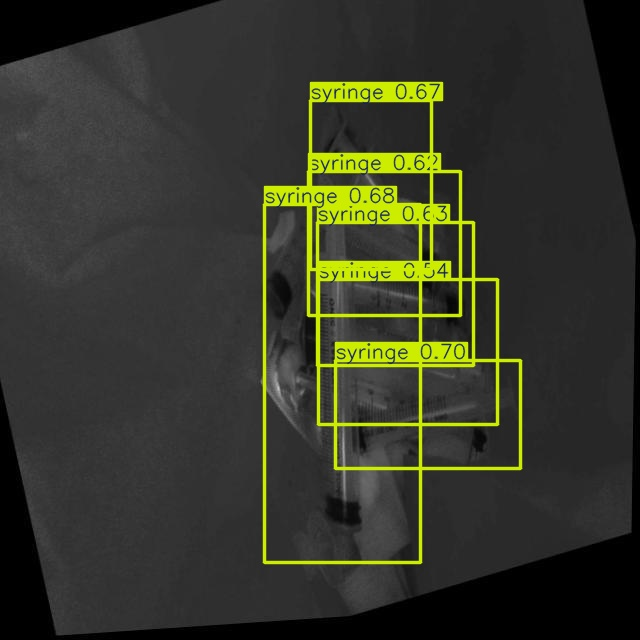

Detections:
Class: syringe                   Confidence: 0.697 BBox: [336.0, 360.9, 520.0, 468.3]
Class: syringe                   Confidence: 0.681 BBox: [264.8, 204.6, 420.1, 562.5]
Class: syringe                   Confidence: 0.669 BBox: [310.9, 100.4, 431.2, 269.7]
Class: syringe                   Confidence: 0.626 BBox: [317.5, 222.5, 473.2, 365.1]
Class: syringe                   Confidence: 0.620 BBox: [308.6, 171.5, 460.9, 315.2]
Class: syringe                   Confidence: 0.541 BBox: [318.9, 279.6, 497.1, 424.2]

Inference on: gloves_237_jpg.rf.1f1465039ec22e71c9e0e16d8d455b69.jpg

image 1/1 /kaggle/input/datasets/anush7/bio-medical-dataset/Biomedical Waste Detection dataset.v1i.yolov11/test/images/gloves_237_jpg.rf.1f1465039ec22e71c9e0e16d8d455b69.jpg: 640x640 2 gloves, 8.0ms
Speed: 2.3ms preprocess, 8.0ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/inference_results


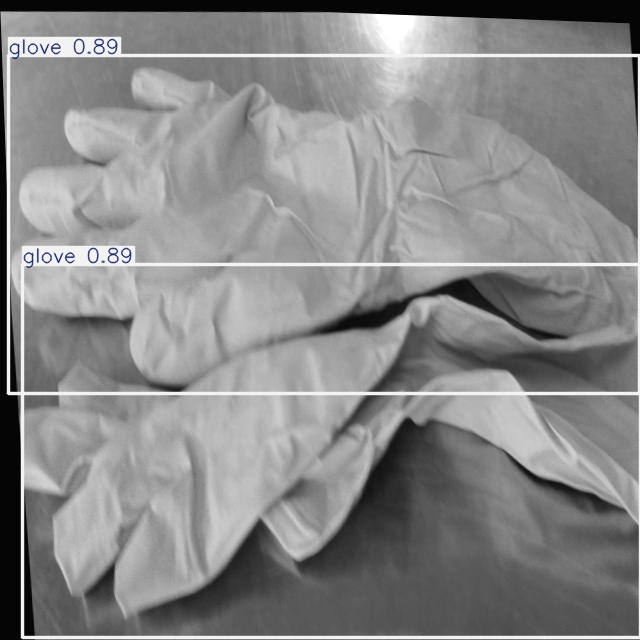

Detections:
Class: glove                     Confidence: 0.891 BBox: [23.0, 264.0, 640.0, 637.3]
Class: glove                     Confidence: 0.890 BBox: [8.3, 55.4, 639.4, 393.5]

Inference on: gloves_284_jpg.rf.e466cc29b0cc190f5ea13bce5a010168.jpg

image 1/1 /kaggle/input/datasets/anush7/bio-medical-dataset/Biomedical Waste Detection dataset.v1i.yolov11/test/images/gloves_284_jpg.rf.e466cc29b0cc190f5ea13bce5a010168.jpg: 640x640 2 gloves, 7.9ms
Speed: 1.5ms preprocess, 7.9ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/inference_results


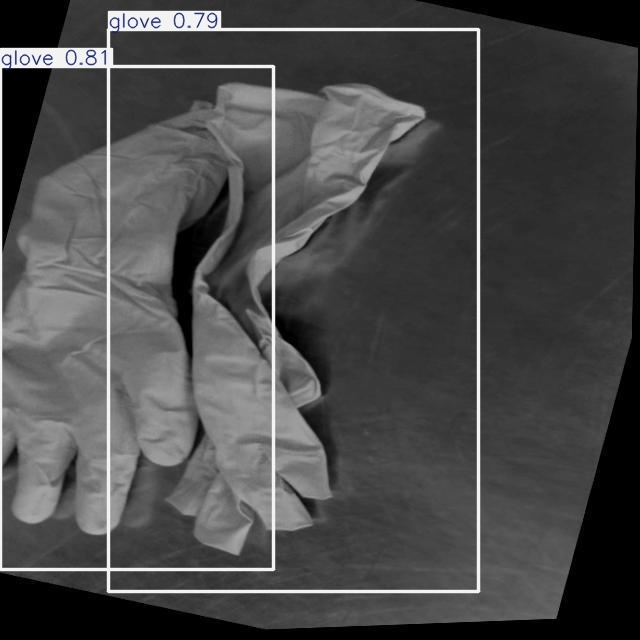

Detections:
Class: glove                     Confidence: 0.810 BBox: [0.1, 66.1, 273.4, 569.3]
Class: glove                     Confidence: 0.786 BBox: [108.4, 29.9, 478.3, 591.7]

Inference on: paper_437_jpg.rf.92d4e3b2f14ee52ea70f803df18ef2e8.jpg

image 1/1 /kaggle/input/datasets/anush7/bio-medical-dataset/Biomedical Waste Detection dataset.v1i.yolov11/test/images/paper_437_jpg.rf.92d4e3b2f14ee52ea70f803df18ef2e8.jpg: 640x640 1 general_waste, 7.8ms
Speed: 1.4ms preprocess, 7.8ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/inference_results


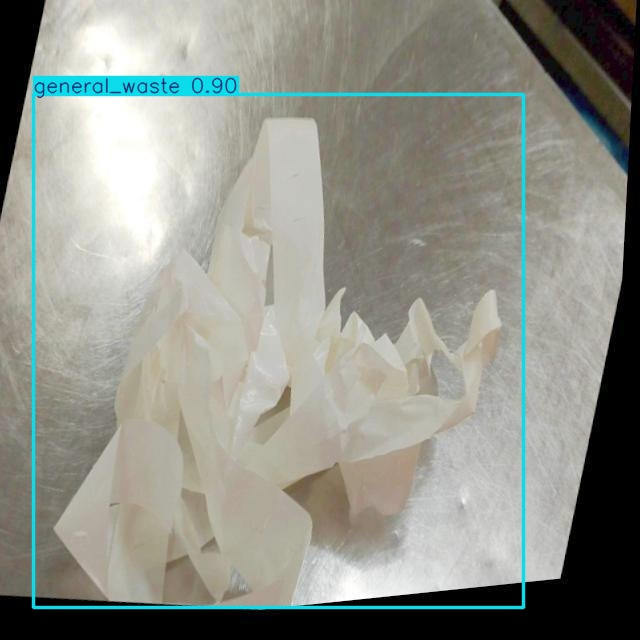

Detections:
Class: general_waste             Confidence: 0.899 BBox: [33.8, 94.2, 523.5, 607.2]

Inference on: needles_529_jpg.rf.fd26dd348b436ed6c842089395182600.jpg

image 1/1 /kaggle/input/datasets/anush7/bio-medical-dataset/Biomedical Waste Detection dataset.v1i.yolov11/test/images/needles_529_jpg.rf.fd26dd348b436ed6c842089395182600.jpg: 640x640 1 needle, 8.5ms
Speed: 1.3ms preprocess, 8.5ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/inference_results


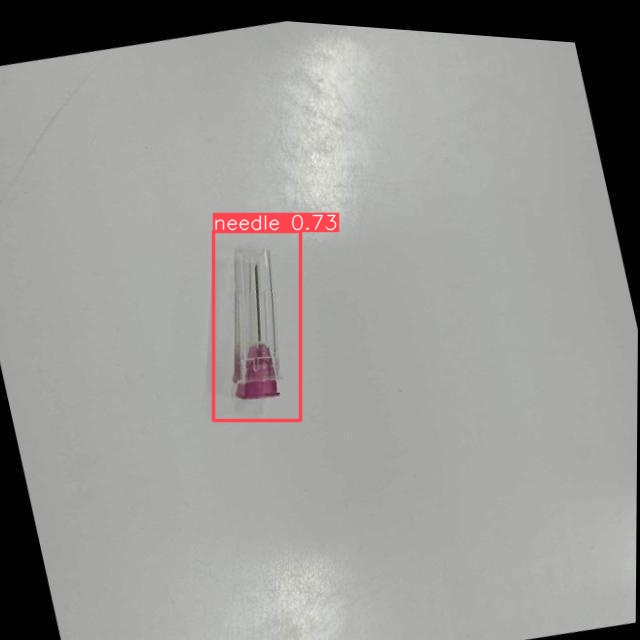

Detections:
Class: needle                    Confidence: 0.734 BBox: [213.7, 231.8, 300.3, 420.2]

✅ Inference completed.
Annotated images saved in:
/kaggle/working/inference_results


In [51]:
import os
from ultralytics import YOLO
from IPython.display import Image, display

# ==================================
# Load Trained Model
# ==================================
best_model_path = "/kaggle/working/Biomedical_Waste/weights/best.pt"

try:
    inference_model = YOLO(best_model_path)
    print(f"✅ Loaded model: {best_model_path}")

except Exception as e:
    print(f"❌ Error loading model: {e}")
    inference_model = None

# ==================================
# Run Inference on Test Images
# ==================================
if inference_model:

    test_images_dir = "/kaggle/input/datasets/anush7/bio-medical-dataset/Biomedical Waste Detection dataset.v1i.yolov11/test/images"

    test_images = [
        f for f in os.listdir(test_images_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print(f"\nFound {len(test_images)} test images.")

    # Number of images to visualize
    num_images = min(5, len(test_images))

    for image_name in test_images[:num_images]:

        image_path = os.path.join(test_images_dir, image_name)

        print("\n" + "=" * 60)
        print(f"Inference on: {image_name}")

        results = inference_model.predict(
            source=image_path,
            save=True,
            project="/kaggle/working",
            name="inference_results",
            exist_ok=True
        )

        # Display annotated image
        saved_path = os.path.join(
            "/kaggle/working/inference_results",
            image_name
        )

        if os.path.exists(saved_path):
            display(Image(filename=saved_path, width=800))

        # Print detections
        print("Detections:")

        for r in results:

            if len(r.boxes) == 0:
                print("No objects detected.")

            for box in r.boxes:

                cls_id = int(box.cls[0])
                conf = float(box.conf[0])

                class_name = inference_model.names[cls_id]

                x1, y1, x2, y2 = box.xyxy[0].tolist()

                print(
                    f"Class: {class_name:25s} "
                    f"Confidence: {conf:.3f} "
                    f"BBox: [{x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f}]"
                )

    print("\n✅ Inference completed.")
    print("Annotated images saved in:")
    print("/kaggle/working/inference_results")

Although Roboflow achieved validation metrics of mAP@50 = 95.5%, Precision = 91.4%, Recall = 95.4%, and F1 Score = 93.3%, Google Colab was used to obtain a deployable local YOLOv11 Nano model due to hardware limitations of the development laptop. The training on Colab successfully produced a `best.pt` model, enabling further development and deployment for the AI-BASED MEDICAL WASTE SEGREGATION MONITORING SYSTEM.